In [1]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.train_utils import compare_models, evaluate_and_save

In [2]:
df = pd.read_csv("../data/heart.csv")
print("Before:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)
print(df["target"].value_counts())
df.head()

Before: (1025, 14)
After removing duplicates: (302, 14)
target
1    164
0    138
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


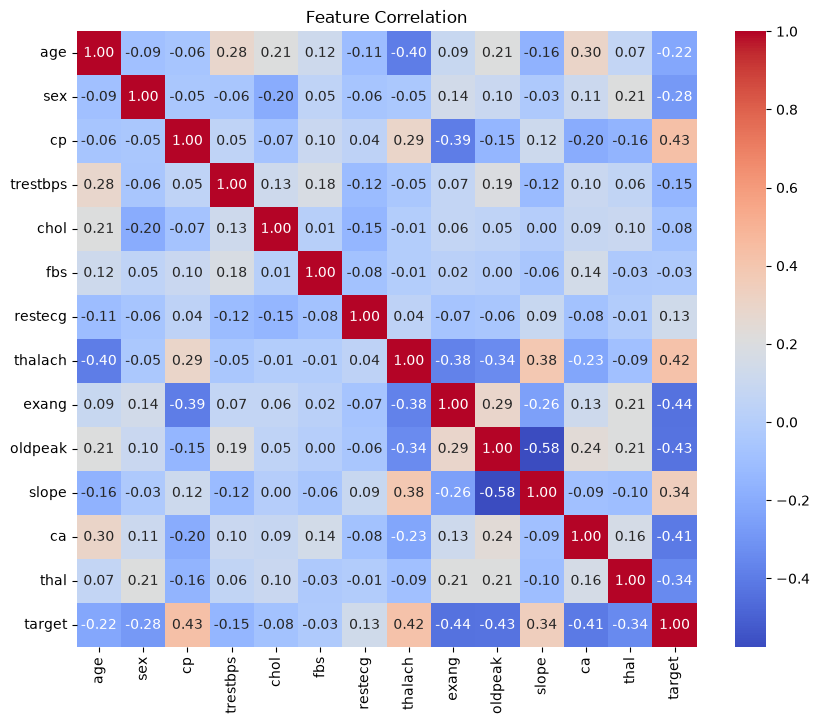

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation")
plt.savefig("../assets/heart_correlation.png", bbox_inches="tight")
plt.show()

In [4]:
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
results = compare_models(X_train, y_train)
results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.838,0.828,0.901,0.860,0.914
1,SVM,0.850,0.836,0.908,0.869,0.913
2,Random Forest,0.842,0.842,0.885,0.860,0.905
3,Gradient Boosting,0.826,0.816,0.885,0.847,0.888


Best model: Logistic Regression
               precision    recall  f1-score   support

   No Disease       0.81      0.75      0.78        28
Heart Disease       0.80      0.85      0.82        33

     accuracy                           0.80        61
    macro avg       0.80      0.80      0.80        61
 weighted avg       0.80      0.80      0.80        61



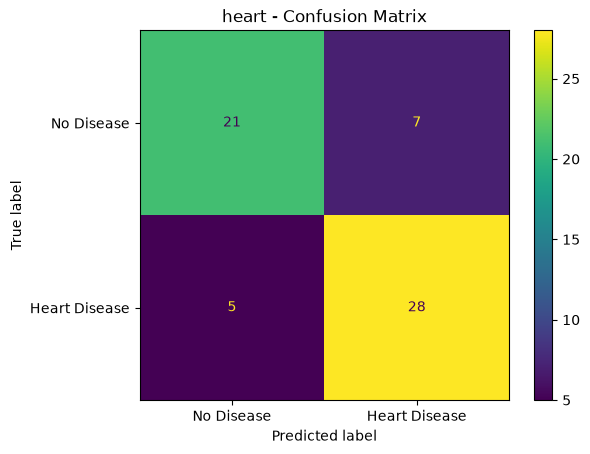

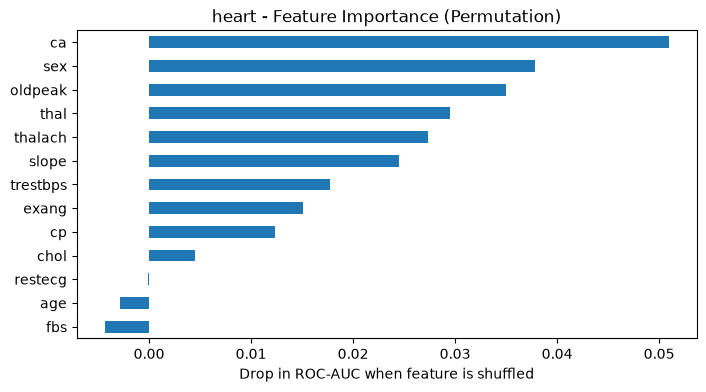

Saved models/heart_model.joblib | Test ROC-AUC: 0.871


In [5]:
_ = evaluate_and_save(results, X, X_train, X_test, y_train, y_test,
                      tag="heart", labels=["No Disease", "Heart Disease"])